# YUVAA Virtual Internship — Week 6
## Reflective Analysis and Future Forecasting in Agribusiness

**Prepared by:** Avirup Karmakar

This notebook consolidates the complete six-week agribusiness analytics workflow. It combines reflective analysis, validation of the previous weeks' methods, a transparent baseline forecast, supporting visualizations, and recommendations for future data-driven improvements.

## 1. Executive Summary

The project progressed from data collection and cleaning in Week 1 to visualization and insight generation in Week 2, statistical analysis and baseline forecasting in Week 3, scenario and risk assessment in Week 4, and strategic recommendation and operational planning in Week 5. Week 6 reviews that full workflow and develops a forward-looking analytical plan.

A key methodological lesson was that the meaning of the `Season` field matters during aggregation. The dataset contains both `Whole Year` records and explicit seasonal records. Adding both groups together can double-count production, so annual forecasting uses only `Whole Year` records, while seasonal comparisons explicitly exclude them. Rows with missing `Production` are removed rather than converted to zero.

The baseline forecast is intentionally simple and interpretable. It uses a linear trend on the comparable 1997–2014 `Whole Year` annual series. The model is a planning baseline rather than a guaranteed prediction because the dataset does not contain important external drivers such as weather, irrigation, soil, market and policy variables.

## 2. Environment and Data Loading

The notebook uses Python with Pandas, NumPy, Matplotlib, SciPy, and Scikit-learn. It expects the supplied file `crop_production(1).csv` to be in `/mnt/data/`. If the notebook is moved to another folder, change `DATA_PATH` accordingly.

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = Path('crop_production.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('crop_production.csv')

assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'

df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded: {DATA_PATH}')
print(f'Rows: {len(df_raw):,} | Columns: {len(df_raw.columns)}')
df_raw.head()

Loaded: crop_production.csv
Rows: 246,091 | Columns: 8


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## 3. Data Cleaning and Reproducibility

The cleaning approach follows the decisions made in the earlier weeks:

- Remove rows where `Production` is missing; a missing value is not assumed to be zero production.
- Trim whitespace from text fields.
- Ensure `Crop_Year`, `Area`, and `Production` are numeric.
- Remove exact duplicate rows.
- Keep the original crop and production units as supplied by the dataset.

The resulting analytical dataset represents complete production observations, not necessarily every row present in the raw source.

In [21]:
df = df_raw.copy()

text_cols = [c for c in ['State_Name','District_Name','Season','Crop'] if c in df.columns]
for c in text_cols:
    df[c] = df[c].astype('string').str.strip()

numeric_cols = ['Crop_Year', 'Area', 'Production']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

raw_rows = len(df)
missing_production = int(df['Production'].isna().sum())
duplicate_rows = int(df.duplicated().sum())

df = df.dropna(subset=['Production']).drop_duplicates().copy()
analysis_rows = len(df)

print(f'Raw rows: {raw_rows:,}')
print(f'Missing Production removed: {missing_production:,}')
print(f'Duplicate rows removed: {duplicate_rows:,}')
print(f'Final analytical rows: {analysis_rows:,}')

print('\nMissing values after cleaning:')
print(df.isna().sum())

Raw rows: 246,091
Missing Production removed: 3,730
Duplicate rows removed: 0
Final analytical rows: 242,361

Missing values after cleaning:
index            0
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


## 4. Project-at-a-Glance Summary

Before forecasting, this section summarizes the size and categorical coverage of the cleaned dataset. The summary also checks how many observations are explicitly labelled `Whole Year`, which is important for constructing comparable annual totals.

In [22]:
season_norm = df['Season'].astype('string').str.strip().str.lower()
whole_year_mask = season_norm.eq('whole year')

summary = pd.DataFrame({
    'Metric': [
        'Raw rows', 'Usable rows', 'Missing Production removed', 'Exact duplicate rows',
        'States/regions', 'Districts', 'Crops', 'Crop years', 'Whole Year rows'
    ],
    'Value': [
        raw_rows, analysis_rows, missing_production, duplicate_rows,
        df['State_Name'].nunique(), df['District_Name'].nunique(), df['Crop'].nunique(),
        df['Crop_Year'].nunique(), int(whole_year_mask.sum())
    ]
})
summary

,Metric,Value
0,Raw rows,246091
1,Usable rows,242361
2,Missing Production removed,3730
3,Exact duplicate rows,0
4,States/regions,33
5,Districts,646
6,Crops,124
7,Crop years,19
8,Whole Year rows,56127


## 5. Reflective Analysis

### Experience and lessons learned

The strongest lesson from the internship was that analytical quality depends on understanding the dataset before applying statistical methods. Cleaning, aggregation rules, validation, visualization, modelling, and business interpretation are connected stages. A technically correct formula can still produce a misleading result when the underlying field semantics are misunderstood.

### Challenges faced

The project involved missing production values, heterogeneous crops and regions, large row counts, and the presence of annual and seasonal records in the same table. Another challenge was interpreting statistical significance in a large sample: even a small effect can produce a very small p-value.

### Areas for improvement

Future work should use documented data dictionaries, transformation logs, automated quality checks, time-based validation, multiple forecasting candidates, prediction intervals, and external explanatory variables. A stronger workflow should also separate crop-level and district-level models from national aggregates so that local patterns are not hidden by aggregation.

## 6. Reassessing Previous Methodologies

### What worked well

1. Systematic cleaning created a repeatable analytical base.
2. Visualizations improved communication of crop, state, season, and annual patterns.
3. Correlation and regression added quantitative evidence.
4. Scenario analysis connected historical variability with operational planning.
5. Week 5 translated findings into KPIs, timelines, and decision triggers.

### What should be improved

- Annual forecasting should use only comparable annual records and explicitly document exclusions.
- Forecast performance should be measured on holdout or rolling time windows, not only in-sample fit.
- Models should be compared at crop and district levels where enough history exists.
- Future datasets should include a data dictionary, unit definitions, transformation log, and model-version record.
- Forecasts should report uncertainty rather than only point estimates.

## 7. Correct Annual Aggregation Rule

For annual analysis, only rows labelled `Whole Year` are used. This avoids double-counting when a year contains both an aggregate annual record and separate seasonal records. The source data contain `Whole Year` records for 1997–2014. No `Whole Year` records are present for 2015, so 2015 is not treated as a directly comparable annual observation in the baseline trend model.

In [23]:
annual = (
    df.loc[whole_year_mask]
      .groupby('Crop_Year', as_index=False)['Production']
      .sum()
      .sort_values('Crop_Year')
)

print('Comparable annual years:', int(annual['Crop_Year'].min()), 'to', int(annual['Crop_Year'].max()))
print('Number of annual observations:', len(annual))
annual

Comparable annual years: 1997 to 2014
Number of annual observations: 18


,Crop_Year,Production
0,1997,5.609452e+08
1,1998,5.535654e+09
2,1999,6.188821e+09
3,2000,7.215519e+09
4,2001,7.213718e+09
5,2002,7.480023e+09
6,2003,7.653894e+09
7,2004,7.809631e+09
8,2005,7.613276e+09
9,2006,8.265369e+09


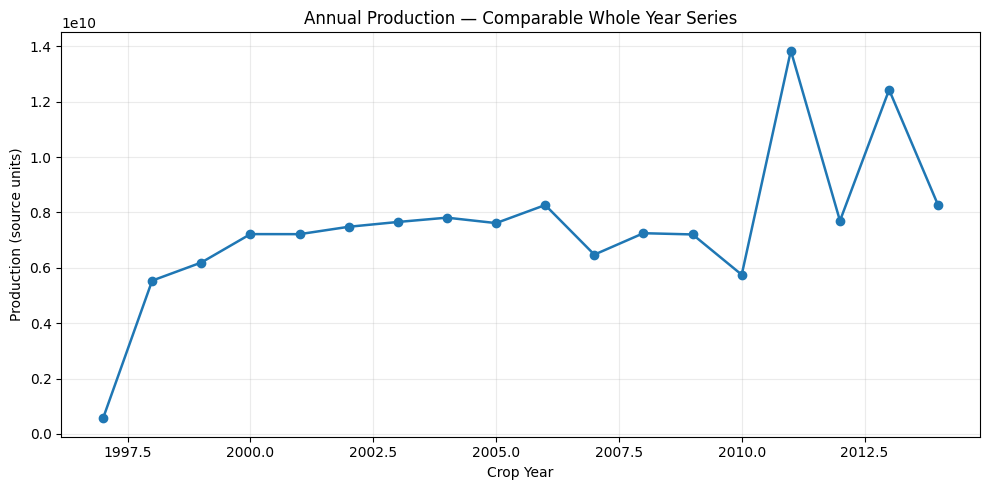

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(annual['Crop_Year'], annual['Production'], marker='o', linewidth=1.8)
plt.title('Annual Production — Comparable Whole Year Series')
plt.xlabel('Crop Year')
plt.ylabel('Production (source units)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Baseline Future Forecast

A linear trend is fitted to annual production for 1997–2014. This model is deliberately simple and transparent. It answers a narrow question: what level would the historical linear direction imply for the next five years? It does not claim that weather, policy, prices, technology, extreme events, or structural changes will remain constant.

In [25]:
X = annual[['Crop_Year']].values
y = annual['Production'].values

trend_model = LinearRegression()
trend_model.fit(X, y)

y_fit = trend_model.predict(X)
mae = mean_absolute_error(y, y_fit)
rmse = np.sqrt(mean_squared_error(y, y_fit))
r2 = r2_score(y, y_fit)
cv = (np.std(y, ddof=1) / np.mean(y)) * 100

last_year = int(annual['Crop_Year'].max())
forecast_years = np.arange(last_year + 2, last_year + 7)  # 2016–2020
forecast_values = trend_model.predict(forecast_years.reshape(-1, 1))

forecast = pd.DataFrame({
    'Year': forecast_years,
    'Forecast_Production': forecast_values
})

metrics = pd.DataFrame({
    'Metric': ['Slope per year', 'Intercept', 'R²', 'MAE', 'RMSE', 'Annual CV (%)'],
    'Value': [trend_model.coef_[0], trend_model.intercept_, r2, mae, rmse, cv]
})
print('Trend-model diagnostics')
metrics

Trend-model diagnostics


,Metric,Value
0,Slope per year,3.158448e+08
1,Intercept,-6.259587e+11
2,R²,3.899324e-01
3,MAE,1.659906e+09
4,RMSE,2.049645e+09
5,Annual CV (%),3.615717e+01


In [26]:
forecast_display = forecast.copy()
forecast_display['Forecast_Production'] = forecast_display['Forecast_Production'].round(2)
forecast_display

,Year,Forecast_Production
0,2016,1.078442e+10
1,2017,1.110026e+10
2,2018,1.141611e+10
3,2019,1.173195e+10
4,2020,1.204780e+10


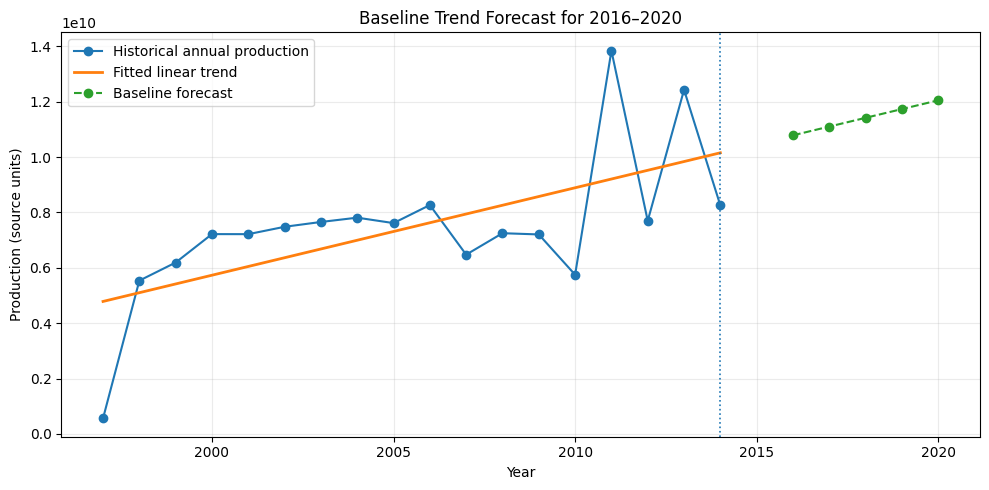

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(annual['Crop_Year'], y, marker='o', label='Historical annual production')
plt.plot(annual['Crop_Year'], y_fit, linewidth=2, label='Fitted linear trend')
plt.plot(forecast['Year'], forecast['Forecast_Production'], marker='o', linestyle='--', label='Baseline forecast')
plt.axvline(last_year, linestyle=':', linewidth=1.2)
plt.title('Baseline Trend Forecast for 2016–2020')
plt.xlabel('Year')
plt.ylabel('Production (source units)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Forecast interpretation

The model projects an upward linear baseline from roughly **10.78 billion** source units in 2016 to roughly **12.05 billion** in 2020. However, the in-sample **R² is about 0.390**, with **MAE about 1.66 billion** and **RMSE about 2.05 billion**. The model therefore leaves a substantial share of historical variation unexplained. The forecast should be used as a capacity-planning reference and monitoring baseline, not as a precise prediction.

## 9. Area–Production Statistical Check

The earlier weeks used correlation and regression to examine whether larger cultivated area was associated with higher recorded production at row level. This notebook reproduces the same diagnostic. Because the dataset is large and heterogeneous across crops and regions, the result should not be interpreted as a causal estimate.

In [28]:
pair = df[['Area', 'Production']].dropna().copy()
pearson_r, p_value = stats.pearsonr(pair['Area'], pair['Production'])

area_model = LinearRegression()
area_model.fit(pair[['Area']], pair['Production'])
area_pred = area_model.predict(pair[['Area']])
area_mae = mean_absolute_error(pair['Production'], area_pred)
area_rmse = np.sqrt(mean_squared_error(pair['Production'], area_pred))
area_r2 = r2_score(pair['Production'], area_pred)

print(f'Pearson r = {pearson_r:.4f}')
print(f'p-value   = {p_value:.4g}')
print(f'Linear regression R² = {area_r2:.4f}')
print(f'MAE = {area_mae:,.2f}')
print(f'RMSE = {area_rmse:,.2f}')

Pearson r = 0.0406
p-value   = 6.808e-89
Linear regression R² = 0.0016
MAE = 1,095,705.53
RMSE = 17,051,715.57


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


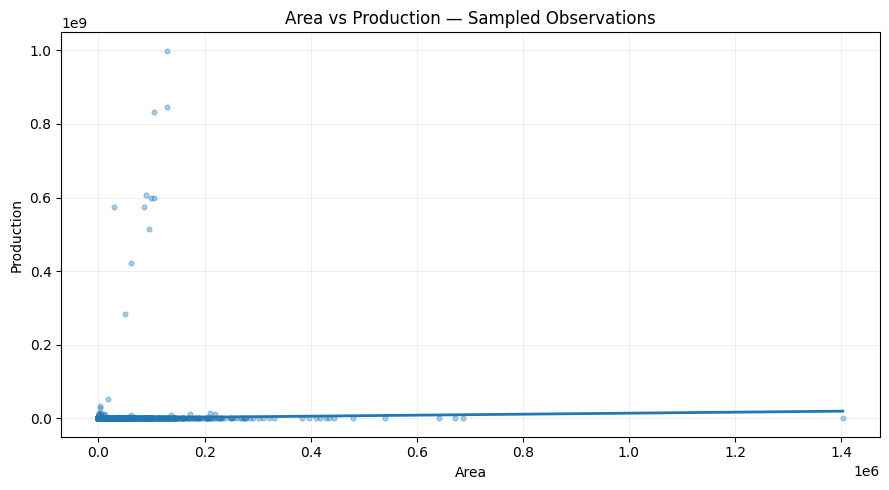

In [29]:
sample = pair.sample(min(5000, len(pair)), random_state=42)
plt.figure(figsize=(9, 5))
plt.scatter(sample['Area'], sample['Production'], alpha=0.35, s=12)
line_x = np.linspace(sample['Area'].min(), sample['Area'].max(), 100)
line_y = area_model.predict(line_x.reshape(-1, 1))
plt.plot(line_x, line_y, linewidth=2)
plt.title('Area vs Production — Sampled Observations')
plt.xlabel('Area')
plt.ylabel('Production')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The row-level Pearson correlation is approximately **0.0406**, which is a very weak linear association even though the p-value is extremely small because the sample is large. This demonstrates an important statistical lesson: statistical significance does not automatically mean practical significance. Crop type, location, season, yield differences, measurement units, climate, irrigation, input intensity and other factors can strongly affect production.

## 10. Seasonal Production Profile

For seasonal comparisons, `Whole Year` rows are excluded. This prevents annual aggregate rows from competing with actual season records.

In [30]:
seasonal = (
    df.loc[~whole_year_mask]
      .groupby('Season', as_index=False)['Production']
      .sum()
      .sort_values('Production', ascending=False)
)
seasonal['Share_%'] = seasonal['Production'] / seasonal['Production'].sum() * 100
seasonal

,Season,Production,Share_%
1,Kharif,4.029970e+09,59.691950
2,Rabi,2.051688e+09,30.389611
4,Winter,4.345498e+08,6.436555
3,Summer,1.706579e+08,2.527786
0,Autumn,6.441377e+07,0.954097


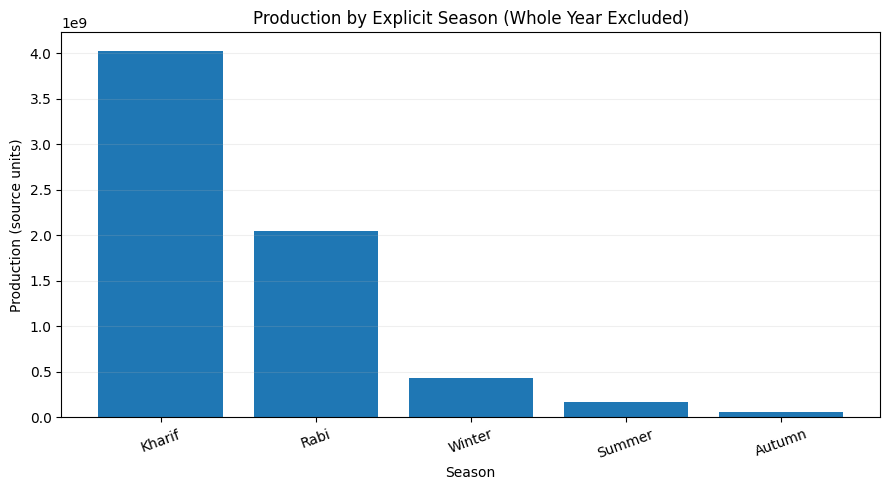

In [31]:
plt.figure(figsize=(9, 5))
plt.bar(seasonal['Season'], seasonal['Production'])
plt.title('Production by Explicit Season (Whole Year Excluded)')
plt.xlabel('Season')
plt.ylabel('Production (source units)')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

Kharif contributes approximately **59.69%** of explicit-season production in this dataset, followed by Rabi at approximately **30.39%**. This concentration supports the operational planning idea developed in Week 5: procurement readiness, storage capacity and monitoring should be aligned with seasonal peaks rather than distributed uniformly across the year.

## 11. Regional Concentration

The following chart summarizes `Whole Year` production by state/region. This is a dataset-level concentration view, not a universal ranking of agricultural output. The dataset mixes many crops and retains the source units.

In [32]:
state_totals = (
    df.loc[whole_year_mask]
      .groupby('State_Name')['Production']
      .sum()
      .sort_values(ascending=False)
)
top_states = state_totals.head(10)
top5_share = top_states.head(5).sum() / state_totals.sum() * 100
print(f'Top-5 state share of recorded Whole Year production: {top5_share:.2f}%')
top_states.to_frame('Production')

Top-5 state share of recorded Whole Year production: 96.48%


,Production
State_Name,
Kerala,9.786933e+10
Andhra Pradesh,1.702610e+10
Tamil Nadu,1.194169e+10
Assam,1.996667e+09
Uttar Pradesh,8.608339e+08
West Bengal,8.318128e+08
Andaman and Nicobar Islands,7.179722e+08
Maharashtra,6.532872e+08
Karnataka,6.249888e+08


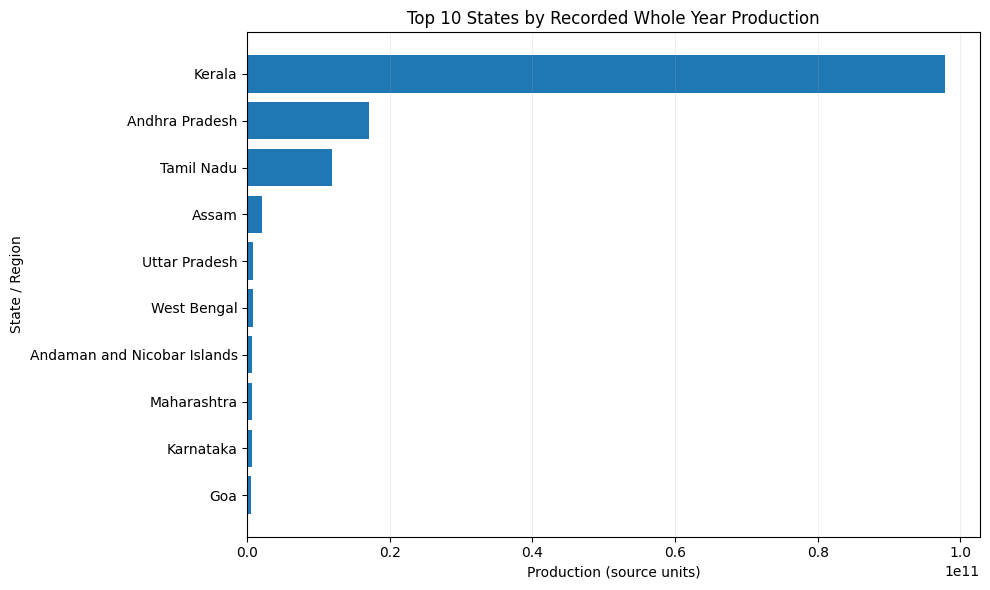

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(top_states.index[::-1], top_states.values[::-1])
plt.title('Top 10 States by Recorded Whole Year Production')
plt.xlabel('Production (source units)')
plt.ylabel('State / Region')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

The five largest states/regions account for approximately **96.48%** of recorded `Whole Year` production in this dataset. This is an important concentration signal for operational planning, but the figure should not be generalized beyond the dataset because crop mix and source-unit definitions influence the total.

## 12. Top Crop Concentration

The crop-level view reinforces the need to validate measurement units before comparing production totals directly across very different crops.

In [34]:
crop_totals = (
    df.loc[whole_year_mask]
      .groupby('Crop')['Production']
      .sum()
      .sort_values(ascending=False)
)
top_crops = crop_totals.head(10)
top_crops.to_frame('Production')

,Production
Crop,
Coconut,1.299815e+11
Sugarcane,3.745173e+09
Potato,1.985014e+08
Banana,1.406728e+08
Tapioca,1.039236e+08
Onion,4.451225e+07
Arecanut,2.003399e+07
Rice,1.856645e+07
Pulses total,1.510091e+07


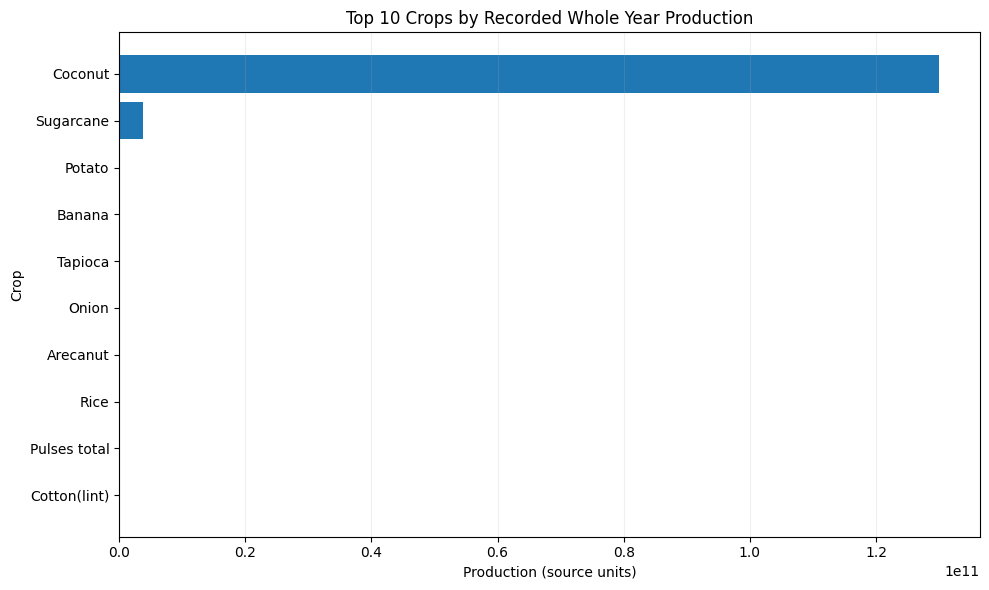

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(top_crops.index[::-1], top_crops.values[::-1])
plt.title('Top 10 Crops by Recorded Whole Year Production')
plt.xlabel('Production (source units)')
plt.ylabel('Crop')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

In the source dataset, Coconut is the dominant recorded `Whole Year` production category, followed by Sugarcane and other lower-volume crops. Because the table combines different crop types, direct comparison of raw production totals should be treated cautiously until units and definitions are verified.

## 13. Scenario-Planning Link to Week 5

The Week 4 and Week 5 work used simple sensitivity scenarios rather than probability forecasts. Applying ±10% and ±20% bands around the baseline forecast provides an operational stress-test range. These are planning assumptions only.

In [36]:
scenario = forecast.copy()
scenario['Favorable (+10%)'] = scenario['Forecast_Production'] * 1.10
scenario['Baseline'] = scenario['Forecast_Production']
scenario['Moderate disruption (-10%)'] = scenario['Forecast_Production'] * 0.90
scenario['Severe disruption (-20%)'] = scenario['Forecast_Production'] * 0.80
scenario[['Year','Favorable (+10%)','Baseline','Moderate disruption (-10%)','Severe disruption (-20%)']]

,Year,Favorable (+10%),Baseline,Moderate disruption (-10%),Severe disruption (-20%)
0,2016,1.186286e+10,1.078442e+10,9.705975e+09,8.627533e+09
1,2017,1.221029e+10,1.110026e+10,9.990235e+09,8.880209e+09
2,2018,1.255772e+10,1.141611e+10,1.027450e+10,9.132885e+09
3,2019,1.290515e+10,1.173195e+10,1.055876e+10,9.385561e+09
4,2020,1.325258e+10,1.204780e+10,1.084302e+10,9.638237e+09


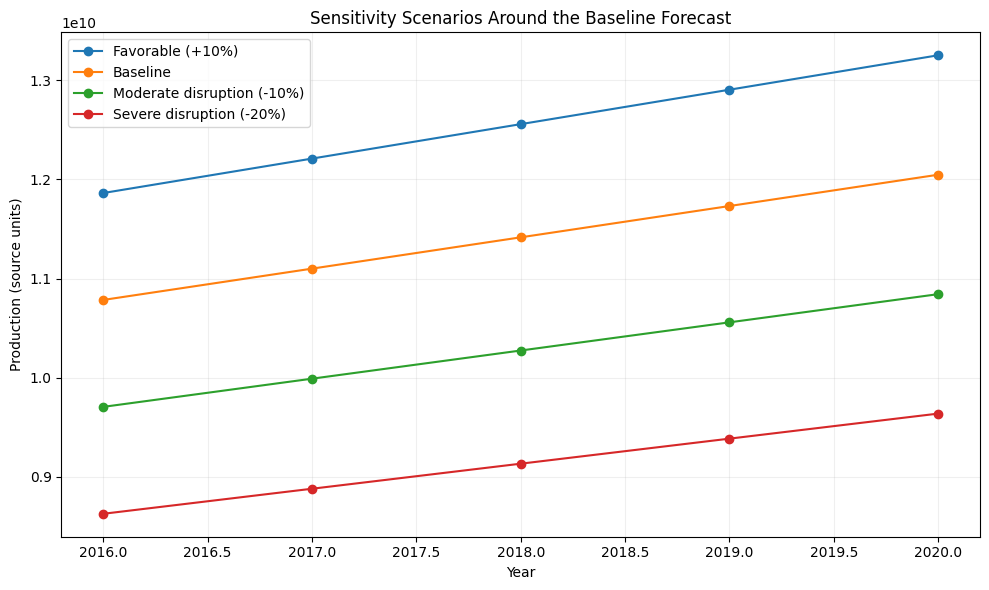

In [37]:
plt.figure(figsize=(10, 6))
for col in ['Favorable (+10%)','Baseline','Moderate disruption (-10%)','Severe disruption (-20%)']:
    plt.plot(scenario['Year'], scenario[col], marker='o', label=col)
plt.title('Sensitivity Scenarios Around the Baseline Forecast')
plt.xlabel('Year')
plt.ylabel('Production (source units)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Future Agribusiness Analytical Outlook

The next generation of the project should evolve from a single-table, single-trend analysis into a multi-source decision-support system. Priority directions include:

**Weather-aware forecasting:** join production with rainfall, temperature, drought indicators and extreme-weather measures.

**Geospatial intelligence:** integrate district coordinates, satellite vegetation indicators, land-use patterns and spatial anomaly detection.

**Model comparison:** benchmark ETS/SARIMA-style models and machine-learning regressors using rolling time splits and out-of-sample error.

**Early-warning analytics:** generate anomaly scores for unusual production, area, season and district patterns.

**Operational dashboards:** connect forecast, risk, sourcing and storage KPIs in Power BI or Tableau.

**Data governance and automation:** schedule refreshes, maintain a data dictionary, record transformations, version models, and track forecast errors over time.

## 15. Actionable Recommendations for Future Projects

| Recommendation | Action | Expected benefit | Main challenge |
|---|---|---|---|
| Multi-source agribusiness data mart | Combine production with weather, soil, irrigation, prices, storage and logistics data | Higher explanatory power and richer scenarios | Data integration and missing fields |
| Forecast model comparison | Use rolling time splits to compare statistical and ML models | Better out-of-sample performance assessment | Leakage prevention and validation design |
| Early-warning dashboard | Track anomalies, forecast error, sourcing concentration and scenario thresholds | Faster operational response | Data refresh reliability |
| Crop/district productivity indicators | Calculate production per area only where units are compatible | Separate area expansion from productivity change | Unit inconsistency and outliers |
| Uncertainty-aware forecasting | Add prediction intervals and scenario ranges | More risk-aware planning | Model assumptions and data quality |

## 16. Suggested 12-Month Improvement Roadmap

**Months 1–2:** establish a data dictionary, source register, transformation log, unit checks, and automated data-quality tests.

**Months 3–4:** integrate weather and market variables and create crop/district-level feature tables.

**Months 5–6:** build baseline statistical models and rolling time-validation pipelines.

**Months 7–8:** compare machine-learning forecasting models and quantify uncertainty.

**Months 9–10:** build an early-warning and operational KPI dashboard.

**Months 11–12:** conduct backtesting, review errors and update decision thresholds using observed forecast performance.

## 17. Final Reflection and Conclusion

The six-week internship demonstrated a complete progression from raw agribusiness data to evidence-based operational planning. It strengthened practical skills in Python, Pandas, data cleaning, visualization, descriptive and inferential statistics, regression, forecasting, scenario planning, KPI design and strategic communication.

The most important learning was that stronger models do not automatically create stronger decisions. A reliable workflow requires correct data semantics, reproducible transformations, transparent assumptions, validation, uncertainty measurement and careful interpretation. The baseline forecast developed here is useful as a planning reference, but the limited explanatory power and absence of external drivers make it unsuitable as a standalone prediction.

Future versions should therefore become continuously validated decision-support systems that learn from new data. By integrating external variables, comparing models with time-based validation, automating monitoring and presenting uncertainty, the project can progress from descriptive agribusiness analytics toward practical, data-driven planning.

## Appendix — Reproducibility Notes

**Dataset:** `crop_production(1).csv`

**Cleaning:** remove missing `Production`; trim text fields; coerce key numeric fields; remove exact duplicates.

**Annual aggregation:** use only `Season == "Whole Year"`; 2015 is excluded from the annual trend because no Whole Year records are present.

**Seasonal aggregation:** exclude Whole Year rows.

**Core libraries:** Python, Pandas, NumPy, Matplotlib, SciPy, Scikit-learn.

**Important interpretation note:** production values remain in the source data's original units. Since multiple crop types are combined, direct comparison of raw totals across crops should be performed only after confirming compatible units and definitions.